In [1]:
import matplotlib.pyplot as plt
from seagliderOG1 import convertOG1, writers
import xarray as xr
import importlib
import numpy as np
import yaml

from dissipationSML import reading, plotting, interactive, tools_new, utilities_new

In [2]:
import pathlib
parent_dir = pathlib.Path().parent.absolute().parents[0]

In [3]:
import importlib
importlib.reload(reading)
importlib.reload(tools_new)

<module 'dissipationSML.tools_new' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py'>

# Glider Data Processing and Analysis

This notebook is dedicated to **loading, processing, and analyzing oceanographic glider datasets** from the University of Washington Seaglider program. The data corresponds to missions conducted near the Faroe Islands and are publicly available from NOAA’s National Centers for Environmental Information (NCEI).

---

## Glider Missions

- **Overview:** [Seaglider Faroes Missions](https://iop.apl.washington.edu/seaglider/index.php?mission=Faroes)  
- **Data Server:** [NOAA NCEI Seaglider Archive](https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/)

The missions span from 2006 to 2009 and include multiple gliders (e.g., 005, 016, 101) and mission deployments. Below is a detailed breakdown of available missions and folder identifiers:

### November 2006
- 016 early recovered (124 dives) — `016/20061112` bad bad resolution data
- 101 full mission (578 dives) — `101/20061112` bad resolution of data
- 102 full mission (630 dives) — `102/20061112`

### February 2007
- 103 full mission (679 dives) — `103/20070218`
- 105 FSC section (125 dives) — _no folder_
- 104 early recovery (70 dives) — _no folder_

### June 2007
- 101 full mission (453 dives) — `101/20070609`
- 102 early recovery (22 dives) — _no folder_

### September 2007
- 012 partial mission (188 dives) — `012/20070831`
- 104 full mission (371 dives) — `104/20070901`
- 105 full mission (373 dives) — _no folder_

### November 2007
- 016 (452 dives) — `016/20071113`
- 102 (454 dives) — `102/20071113`
- 103 (524 dives) — `103/20071113`

### February 2008
- 014 (70 dives) — `014/20080214`   not at IFR
- 104 (112 dives) — `104/20080214`

### June 2008
- 102 (5 dives) — _no folder_
- 005 (386 dives) — `005/20080606`
- 016 (421 dives) — `016/20080607`

### August 2008
- 105 (13 dives) — _no folder_
- 103 (10 dives) — _no folder_
- 014 (439 dives) — `014/20080222` (_folder name misleading_)

### November 2008
- 104 (1 dive) — _no folder_  
- 101 (338 dives) — `101/20081108`
- 005 (486 dives) — `005/20081106`

### February 2009
- 103 (481 dives) — `103/20090223`
- 104 (4 dives) — _no folder_

### June 2009
- 016 (297 dives) — `016/20090605`
- 105 (346 dives) — _no folder_
- 005 (464 dives) — `005/20090829`

---

## Notebook Workflow

This notebook performs the following key steps:

1. **Data Loading and Conversion:**  
   The raw glider mission data is loaded from the NOAA server and converted into the **OG1 standardized format**, facilitating streamlined analysis across multiple missions.

2. **Visualization and Exploration:**  
   Various types of visualizations are created to explore the glider data, including:
   - **Glider tracks** (map view)
   - **Profile plots** (e.g., temperature/salinity vs. depth)
   - **Section plots** (along-track interpolations)
   - **Technical diagnostics** (e.g., battery voltage, pitch, roll)

3. **Mixed Layer Depth (MLD) Estimation:**  
   The **mixed layer depth** is computed using two separate methods to compare results and assess robustness:
   - **Fixed density threshold approach**
   - **Gradient-based approach**

These analyses support a better understanding of the hydrographic conditions during the glider missions and contribute to broader oceanographic research near the Faroe Islands.

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', options=('005', '012', '014', '016', '101', '102', '103', '104', '105')…

Dropdown(description='Select Mission:', options=('06/08 (dives: 386)', '08/09 (dives: 464)', '11/08 (dives: 48…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/005/20080606/


In [54]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

## 1. Load dataset

In [42]:
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)

File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050001_20081106.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050002_20081106.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050003_20081106.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050004_20081106.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050005_20081106.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050006_20081107.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050007_20081107.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050008_20081107.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20081106/p0050009_20081107.nc
File already exists: /Users/tillmorit

In [43]:
variables_needed = ['TIME','LONGITUDE','LATITUDE','PROFILE_NUMBER','DIVE_NUMBER', # measurment point specific
                    'PITCH', 'ROLL','HEADING',
                    'DEPTH','PRES',
                    'W_M','U_M','GLIDE_SPEED', # vertical and horizontal velocity
                    'TEMP','PSAL', # CTD data
                    'SIGTHETA','SIGMA_T','THETA'] # potential density and temperature
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)

Converting datasets to OG1 format: 100%|██████████| 485/485 [03:37<00:00,  2.23it/s]


In [44]:
### remove spikes from TEMP and PSAL data
importlib.reload(tools_new)
ds_clean = tools_new.remove_spikes(ds,['PSAL','TEMP','SIGTHETA','SIGMA_T'],window=30, n_std=3, grad_th=[0.1,0.5,0.02,0.02])
ds = tools_new.add_SIG1_CT_SA(ds_clean)


/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1307: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1307: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1308: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1308: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx

In [45]:
interactive.interactive_profile(ds)

Output()

In [50]:
ds = tools_new.add_vertical_water_velocity(ds, pitch_min=8, pitch_max=15)

int64


In [51]:
### add global attributes 
ds.attrs['Mission'] = selected_glider['mission']
ds.attrs['Glider'] = selected_glider['glider']

In [52]:
### cut the dataset to the time period of interest
mask = (ds['TIME'] > np.datetime64('2006-01-01')) & (ds['TIME'] < np.datetime64('2009-12-31'))
ds = ds.where(mask, drop=True)

In [53]:
### safe the data
ds.to_netcdf(mission_path + '/all_data.nc')

## 2. Apply LEM

In [55]:
ds = xr.open_dataset(mission_path + '/all_data.nc')

In [56]:
cut_off = 400 #seconds
window_size = 130 #seconds

In [58]:
importlib.reload(tools_new)
ds_filtered = tools_new.highpass_butterworth_time(ds,'W_W',cutoff_period=cut_off,max_interval=40)
ds_filtered = tools_new.add_velocity_scale(ds_filtered,'W_W_HP',window_size_seconds=window_size)
ds_filtered = tools_new.add_unsorted_N2(ds_filtered)
ds_filtered = tools_new.add_adiabatic_sorted_N2(ds_filtered)
ds_filtered = tools_new.LEM_dissipation(ds_filtered,c = 1)

Filtering W_W:   0%|          | 0/770 [00:00<?, ?it/s]

  0%|          | 0/770 [00:00<?, ?it/s]/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:584: RuntimeWarning: invalid value encountered in sqrt
  n_profile[i] = np.sqrt((9.81 / 1027) * (drho / dz))
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:584: RuntimeWarning: invalid value encountered in sqrt
  n_profile[i] = np.sqrt((9.81 / 1027) * (drho / dz))
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:584: RuntimeWarning: invalid value encountered in sqrt
  n_profile[i] = np.sqrt((9.81 / 1027) * (drho / dz))
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:584: RuntimeWarning: invalid value encountered in sqrt
  n_profile[i] = np.sqrt((9.81 / 1027) * (drho / dz))
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:584: RuntimeWarning: invalid value encountered in sqrt
  n_profile[i] = np.sqrt((9.81 / 10

Calculating adiabatic N² for 770 profiles...


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:546: RuntimeWarning: invalid value encountered in sqrt
  SORTED_N_da = xr.DataArray(df['SORTED_N2'].to_numpy()**0.5, dims=dims, attrs={


In [10]:
importlib.reload(tools_new)
ds_filt_space = tools_new.highpass_butterworth_depth(ds, 'W_W', cutoff=30, max_interval=10)
ds_filt_space = tools_new.add_velocity_scale(ds_filt_space, 'W_W_HP', window_size_seconds=10, axis="DEPTH")
ds_filt_space = tools_new.add_unsorted_N2(ds_filt_space)
ds_filt_space = tools_new.LEM_dissipation(ds_filt_space,c = 0.07)
ds_filt_space = tools_new.add_adiabatic_sorted_N2(ds_filt_space)

100%|██████████| 770/770 [00:07<00:00, 100.13it/s]
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:589: RuntimeWarning: invalid value encountered in sqrt
  n_all = xr.DataArray(np.sqrt(n2_all), dims=dims, attrs={
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/xarray/core/computation.py:824: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:499: RuntimeWarning: Mean of empty slice
  rhobar = np.nanmean(rho[icyc])


Calculating adiabatic N² for 770 profiles...


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:546: RuntimeWarning: invalid value encountered in sqrt
  SORTED_N_da = xr.DataArray(df['SORTED_N2'].to_numpy()**0.5, dims=dims, attrs={


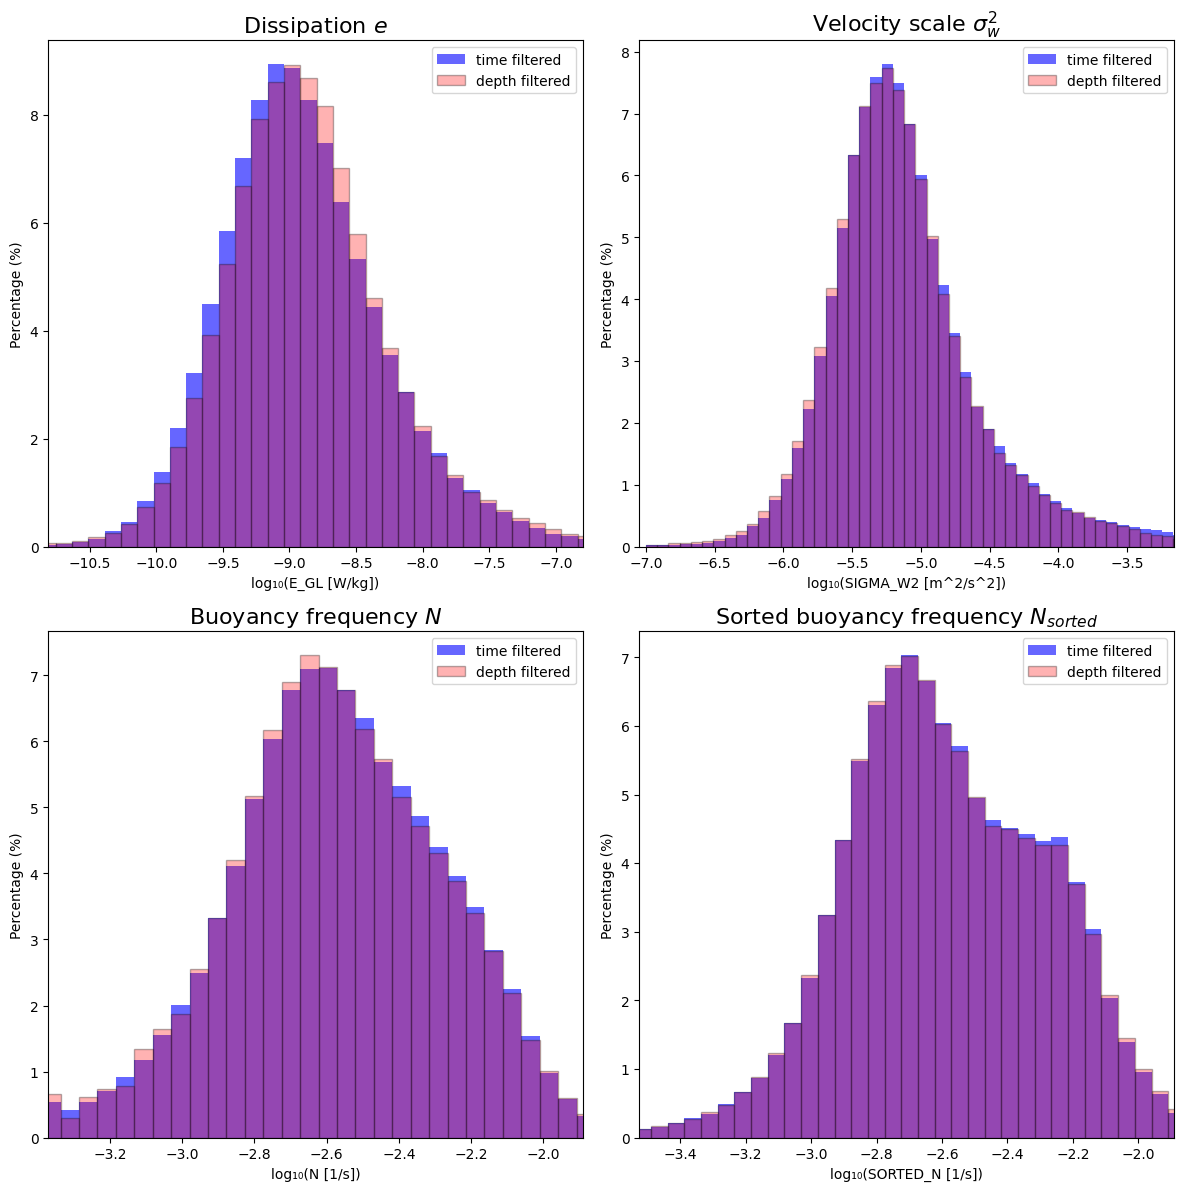

In [24]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax = ax.flatten()
for ds in [ds_filtered, ds_filt_space]:
    if list(ds.sizes.keys())[0] == 'TIME':
        alpha = 0.6
        color = "blue"
        edgecolor = None
        label = "time filtered"
    else:
        alpha = 0.3
        color = "red"
        edgecolor = "black"
        label = "depth filtered"
    bins = np.linspace(-11, -5, 50)
    plotting.plot_histogram(ds, 'E_GL', log_scale = True, style = "Percentage", bins = bins,
                             ax=ax[0], alpha = alpha, color=color, edgecolor=edgecolor, label=label)
    bins = np.linspace(-7, -3, 50)
    plotting.plot_histogram(ds, "SIGMA_W2", log_scale = True, style = "Percentage", bins = bins,
                             ax=ax[1],alpha = alpha, color=color, edgecolor=edgecolor, label=label)
    bins = np.linspace(-4, -1.5, 50)
    plotting.plot_histogram(ds, "N", log_scale = True, style = "Percentage", bins = bins, 
                            ax=ax[2],alpha = alpha, color=color, edgecolor=edgecolor, label=label)
    plotting.plot_histogram(ds, "SORTED_N", log_scale = True, style = "Percentage", bins = bins, 
                            ax=ax[3],alpha = alpha, color=color, edgecolor=edgecolor, label=label)

[axs.legend() for axs in ax]
ax[0].set_title(r'Dissipation $e$',fontsize=16)
ax[1].set_title(r'Velocity scale $\sigma_{w}^{2}$',fontsize=16)
ax[2].set_title(r'Buoyancy frequency $N$',fontsize=16)
ax[3].set_title(r'Sorted buoyancy frequency $N_{sorted}$',fontsize=16)
plt.show()

In [74]:
### make a list which uses four different cut_off
cut_offs = [250, 330, 400, 450] #seconds
ds_list = []
for cut_off in cut_offs:
    ds_filt = tools_new.highpass_butterworth_time(ds,'W_W',cutoff_period=cut_off,max_interval=60)
    ds_list.append(ds_filt)

Filtering W_W: 100%|██████████| 770/770 [00:51<00:00, 14.97it/s]


In [90]:
### for each dataset, try different window sizes for the 
ds_list_250 = []
ds_list_330 = []
ds_list_400 = []
ds_list_450 = []
for window_size in [90, 120, 140, 160]:
    c = 0.062
    ds_filt_250 = tools_new.add_velocity_scale(ds_list[0],'W_W_HP',window_size_seconds=window_size)
    ds_filt_250 = tools_new.add_unsorted_N2(ds_filt_250)
    ds_filt_250['E_GL'] = c * ds_filt_250['SIGMA_W2'] * ds_filt_250['N']
    ds_list_250.append(ds_filt_250)
    
    ds_filt_330 = tools_new.add_velocity_scale(ds_list[1],'W_W_HP',window_size_seconds=window_size)
    ds_filt_330 = tools_new.add_unsorted_N2(ds_filt_330)
    ds_filt_330['E_GL'] = c * ds_filt_330['SIGMA_W2'] * ds_filt_330['N']
    ds_list_330.append(ds_filt_330)

    ds_filt_400 = tools_new.add_velocity_scale(ds_list[2],'W_W_HP',window_size_seconds=window_size)
    ds_filt_400 = tools_new.add_unsorted_N2(ds_filt_400)
    ds_filt_400['E_GL'] = c * ds_filt_400['SIGMA_W2'] * ds_filt_400['N']
    ds_list_400.append(ds_filt_400)

    ds_filt_450 = tools_new.add_velocity_scale(ds_list[3],'W_W_HP',window_size_seconds=window_size)
    ds_filt_450 = tools_new.add_unsorted_N2(ds_filt_450)
    ds_filt_450['E_GL'] = c * ds_filt_450['SIGMA_W2'] * ds_filt_450['N']
    ds_list_450.append(ds_filt_450)
    

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:292: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims = list(ds.dims.keys())[0]
100%|██████████| 770/770 [00:10<00:00, 74.38it/s]
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:491: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims = list(ds.dims.keys())[0]
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:492: RuntimeWarning: invalid value encountered in sqrt
  n_all = xr.DataArray(np.sqrt(n2_all), dims=dims, attrs={
/Users/

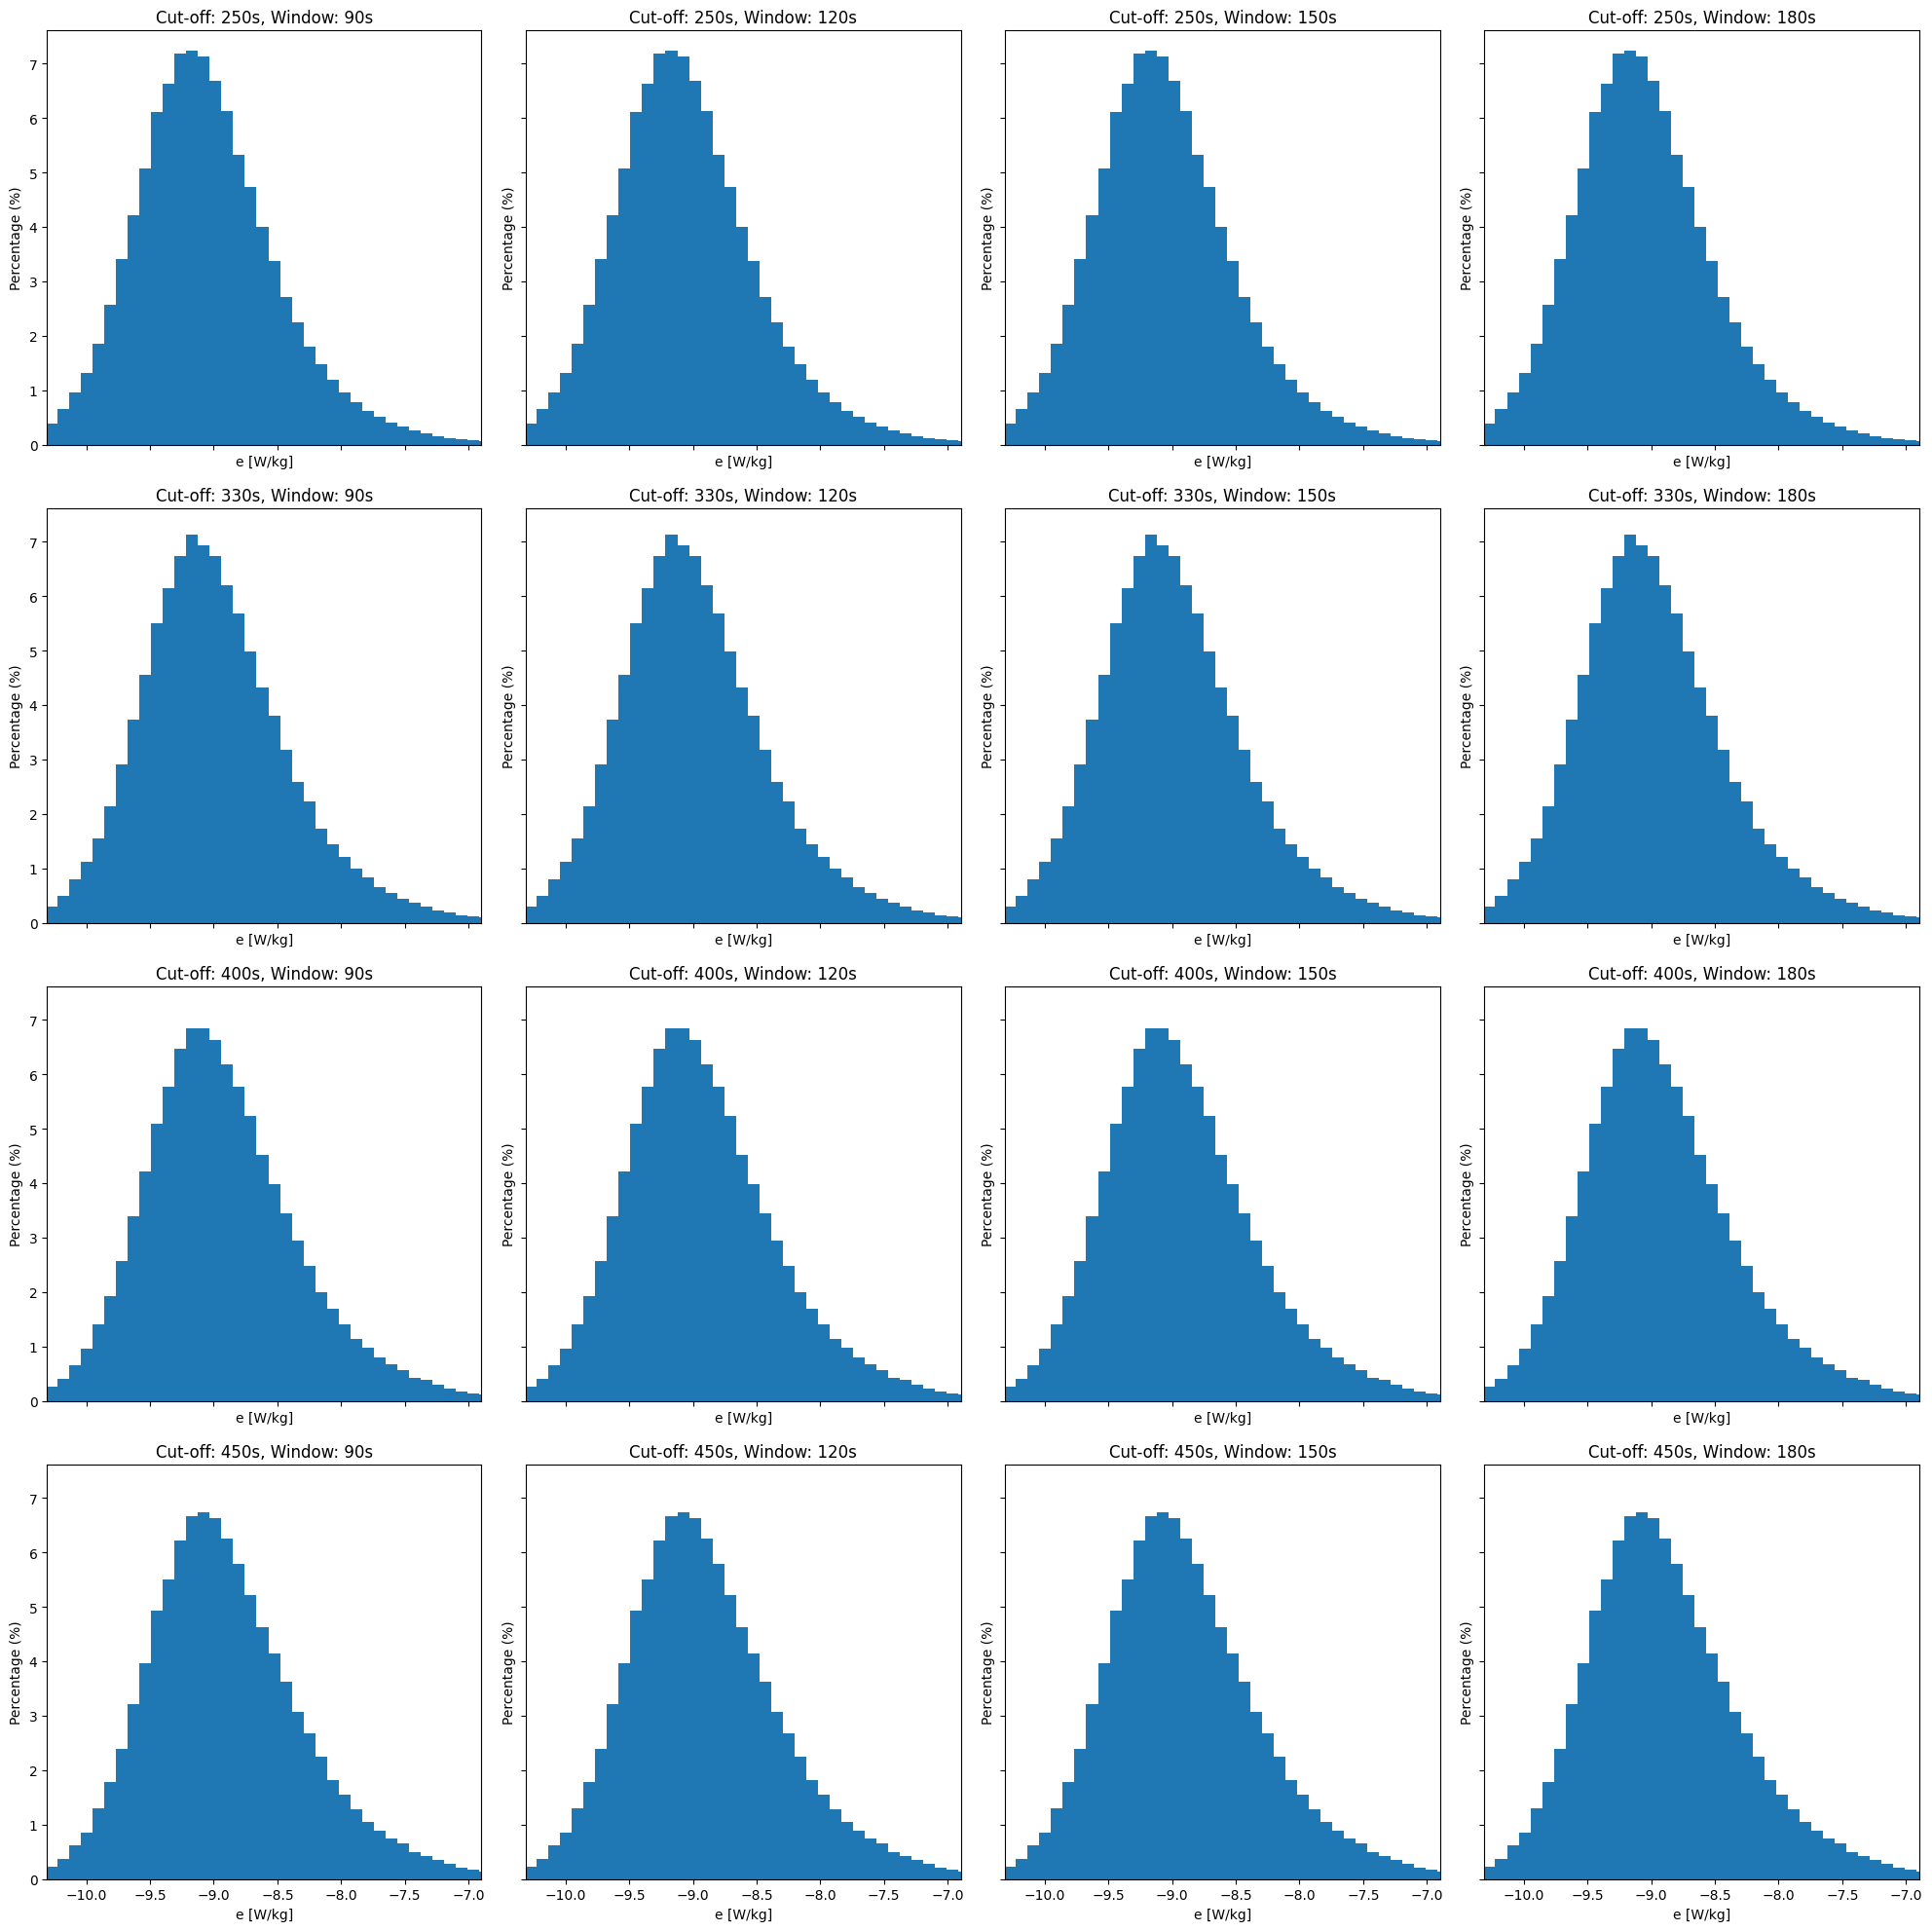

In [98]:
### plot all the different combinations
importlib.reload(plotting)

fig , ax = plt.subplots(4,4, figsize=(20,20), sharey=True, sharex=True)
for i in range(4):
    for j in range(4):
        if i == 0:
            ds_plot = ds_list_250[j]
            cut_off = cut_offs[0]
        elif i == 1:
            ds_plot = ds_list_330[j]
            cut_off = cut_offs[1]
        elif i == 2:
            ds_plot = ds_list_400[j]
            cut_off = cut_offs[2]
        else:
            ds_plot = ds_list_450[j]
            cut_off = cut_offs[3]
        
        bins = np.linspace(-10.5,-6,50)
        plotting.plot_histogram(ds_plot,vars = ['E_GL'], ax=ax[i,j], bins=bins, log_scale=True,style= "Percentage")
        ax[i,j].set_title(f'Cut-off: {cut_off}s, Window: {90 + j*30}s')
        ax[i,j].set_xlabel('e [W/kg]')
        #if j == 0:
        #    ax[i,j].set_ylabel('Probability Density')
plt.show()

In [62]:
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)

### Extract the c value from the bg_yaml
Glider = ds_filtered.attrs['Glider']
Mission = ds_filtered.attrs['Mission']

c = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['c']
print(f'Using c = {c} from bg_dissipation.yaml for glider {Glider} mission {Mission}')

Using c = 0.074 from bg_dissipation.yaml for glider 005 mission 20080606


In [63]:
importlib.reload(tools_new)
ds_final = tools_new.LEM_dissipation(ds_filtered, c = c)

In [64]:
ds_final['E_GL_LOG'] = np.log10(ds_final['E_GL'])

In [65]:
ds_final['N_LOG'] = np.log10(ds_final['N'])
ds_final['SORTED_N_LOG'] = np.log10(ds_final['SORTED_N'])

/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/xarray/core/computation.py:824: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


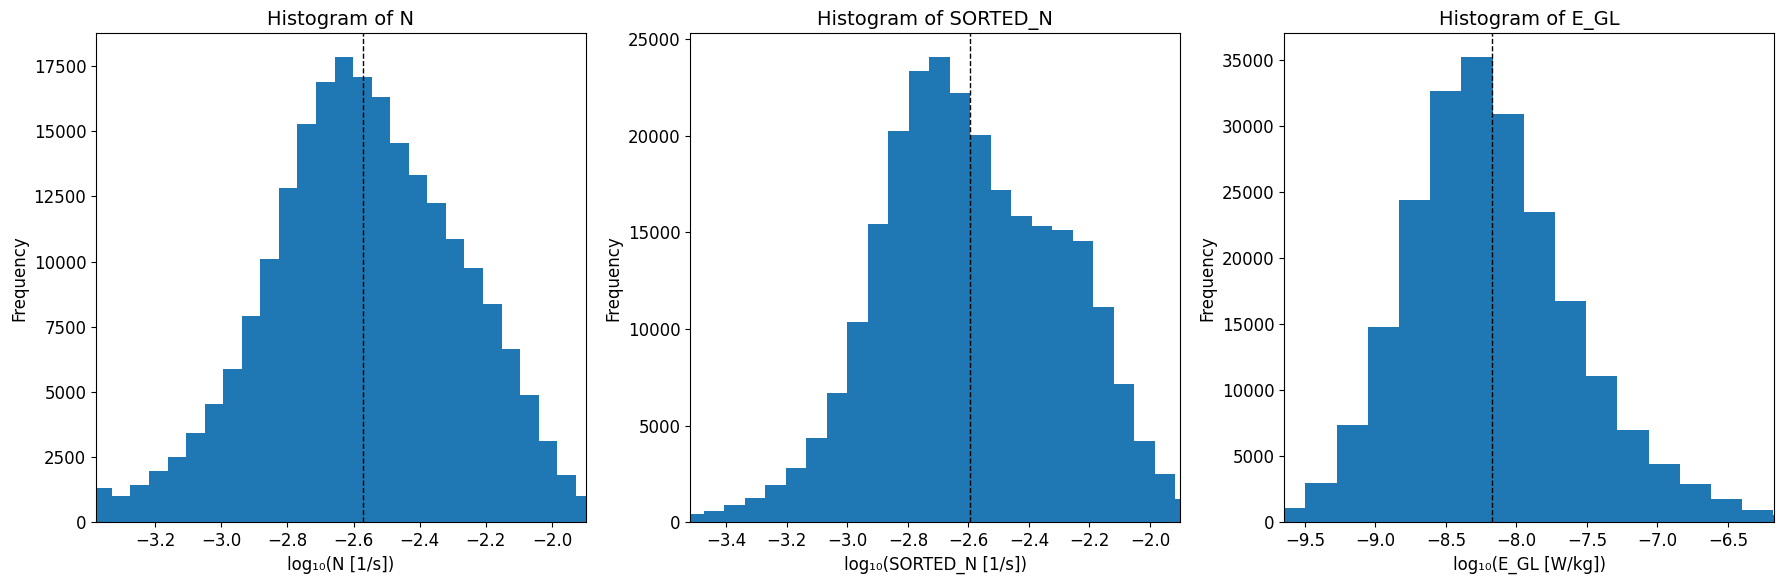

In [48]:
### plot histogram of N_LOG
plotting.plot_histogram(ds_final,["N","SORTED_N","E_GL"],log_scale=True,bins=50)
plt.show()

/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


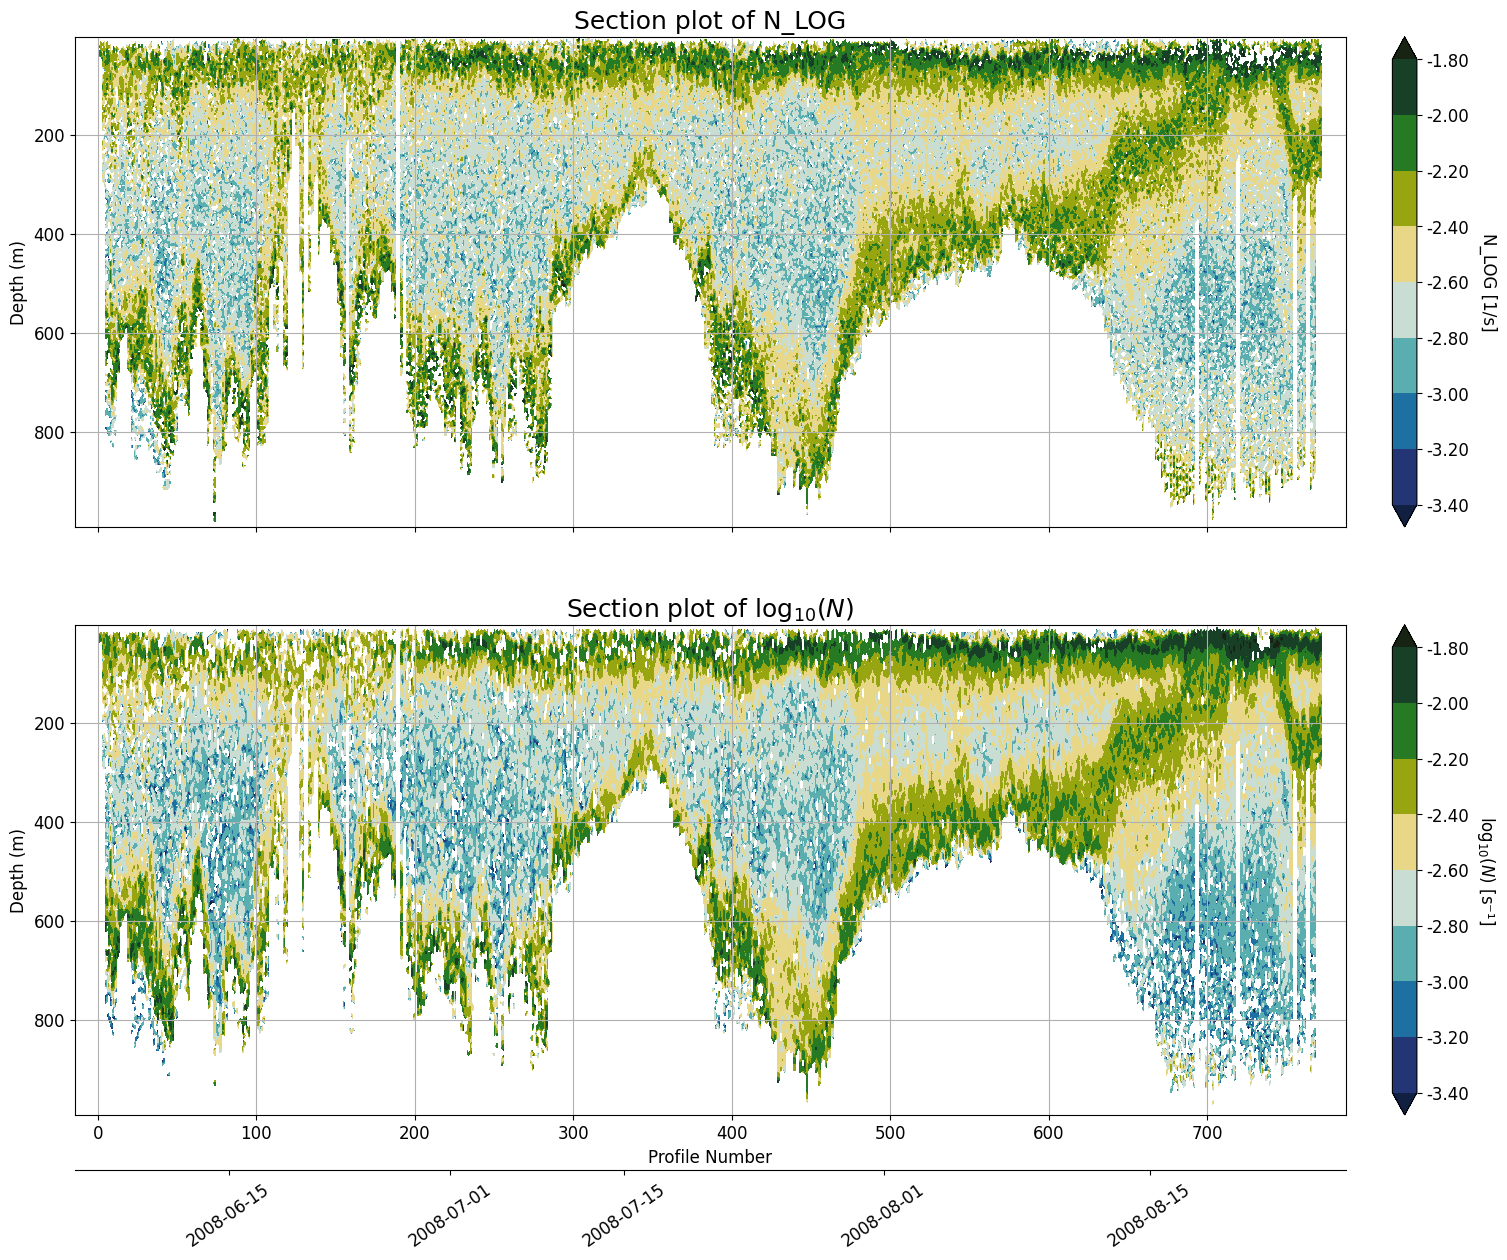

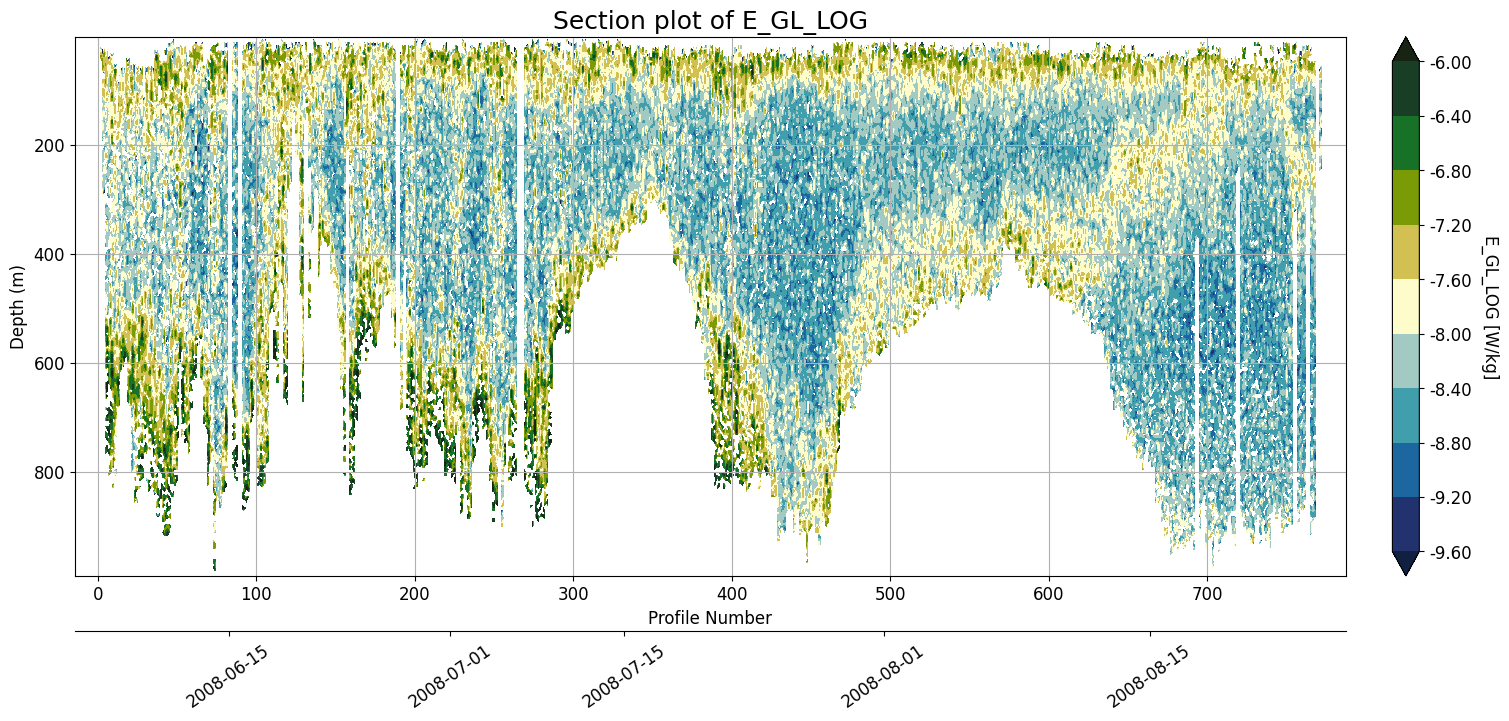

In [51]:
levels = [-1.8,-2,-2.2,-2.4,-2.6,-2.8,-3,-3.2,-3.4]
plotting.plot_section(ds_final,["N_LOG","SORTED_N_LOG"], v_res=5,levels=levels)
levels = [-6,-6.4,-6.8,-7.2,-7.6,-8,-8.4,-8.8,-9.2,-9.6]
plotting.plot_section(ds_final,["E_GL_LOG"], v_res=5,levels=levels)
plt.show()

In [67]:
ds_final.to_netcdf(mission_path + '/original_method.nc')